# Reward-Shaped DQN Extension

## Objective:
Test whether a reward-shaped DQN will improve results compared to the vanilla DQN.

## Controlled experiment:
- Same DQN architecture
- Same environment benchmark
- Different training rewards
- Evaluation will be done on the original benchmark for fairness


In [1]:
from pprint import pprint

from reward_shaping_extension import (
    DEFAULT_CHECKPOINT_DIR,
    DEFAULT_OUTPUT_DIR,
    get_variant_config,
    load_study,
    plot_summary_comparison,
    plot_training_comparison,
    print_study_summary,
    record_variant_video,
    run_failure_analysis,
    run_reward_shaping_study,
    summary_rows,
)


## Experiment settings

- `SEEDS = [0, 1, 2, 3, 4]`
- `TRAIN_EPISODES = 1500`
- `EVAL_EPISODES = 50`

Since here we are reruning both the vanilla and reward-shaped variants its not forcibly necessary alhought more accurate to use the same number of seeds and episodes.

a great prespective for this project is to do that, but for now because of time limitation, huge amount of training time and dce that is timing out on us when we leave it we will stick to theses settings.



In [2]:
SEEDS = [0]
TRAIN_EPISODES = 500
EVAL_EPISODES = 50

OUTPUT_DIR = DEFAULT_OUTPUT_DIR
CHECKPOINT_DIR = DEFAULT_CHECKPOINT_DIR

print('Vanilla reward terms:')
pprint(get_variant_config('vanilla'))
print('\nReward-shaped reward terms:')
pprint(get_variant_config('reward_shaped'))


Vanilla reward terms:
{'action': {'target_speeds': [20, 25, 30], 'type': 'DiscreteMetaAction'},
 'collision_reward': -1.5,
 'controlled_vehicles': 1,
 'duration': 30,
 'ego_spacing': 2,
 'high_speed_reward': 0.7,
 'initial_lane_id': None,
 'lane_change_reward': -0.02,
 'lanes_count': 4,
 'normalize_reward': True,
 'observation': {'absolute': False,
                 'clip': True,
                 'features': ['presence', 'x', 'y', 'vx', 'vy'],
                 'normalize': True,
                 'observe_intentions': False,
                 'see_behind': True,
                 'type': 'Kinematics',
                 'vehicles_count': 10},
 'offroad_terminal': True,
 'reward_speed_range': [22, 30],
 'right_lane_reward': 0.0,
 'vehicles_count': 45,
 'vehicles_density': 1.0}

Reward-shaped reward terms:
{'action': {'target_speeds': [20, 25, 30], 'type': 'DiscreteMetaAction'},
 'collision_reward': -2.5,
 'controlled_vehicles': 1,
 'duration': 30,
 'ego_spacing': 2,
 'high_speed_reward': 0.5,

## Run the extension study

This trains both variants, evaluates them on the original core benchmark, and saves:
- `study.json`
- `summary_table.csv`
- `summary_table.md`
- `training_comparison.png`
- `summary_comparison.png`


In [3]:
study = run_reward_shaping_study(
    seeds=SEEDS,
    train_episodes=TRAIN_EPISODES,
    eval_episodes=EVAL_EPISODES,
    output_dir=OUTPUT_DIR,
    checkpoint_dir=CHECKPOINT_DIR,
)

study['artifacts']



=== Vanilla DQN ===
Training reward terms: {'collision_reward': -1.5, 'right_lane_reward': 0.0, 'high_speed_reward': 0.7, 'lane_change_reward': -0.02, 'normalize_reward': True}

[vanilla | seed 0] training for 500 episodes
  ep   50 | mean_reward=8.823 | crash%=94.0 | eps=1.000
  ep  100 | mean_reward=9.143 | crash%=94.0 | eps=0.984
  ep  150 | mean_reward=8.956 | crash%=92.0 | eps=0.937
  ep  200 | mean_reward=8.961 | crash%=94.0 | eps=0.889
  ep  250 | mean_reward=9.958 | crash%=96.0 | eps=0.838
  ep  300 | mean_reward=7.397 | crash%=96.0 | eps=0.800
  ep  350 | mean_reward=9.240 | crash%=92.0 | eps=0.754
  ep  400 | mean_reward=7.614 | crash%=96.0 | eps=0.715
  ep  450 | mean_reward=8.289 | crash%=96.0 | eps=0.674
  ep  500 | mean_reward=7.602 | crash%=98.0 | eps=0.636

=== Reward-Shaped DQN ===
Training reward terms: {'collision_reward': -2.5, 'right_lane_reward': 0.1, 'high_speed_reward': 0.5, 'lane_change_reward': -0.08, 'normalize_reward': True}

[reward_shaped | seed 0] traini

{'study_json': 'results\\reward_shaping_extension\\study.json',
 'training_plot': 'results\\reward_shaping_extension\\training_comparison.png',
 'summary_plot': 'results\\reward_shaping_extension\\summary_comparison.png',
 'summary_csv': 'results\\reward_shaping_extension\\summary_table.csv',
 'summary_markdown': 'results\\reward_shaping_extension\\summary_table.md'}

In [4]:
print_study_summary(study)
summary_rows(study)



Reward-shaping extension summary
Does simple reward shaping produce a safer DQN policy on highway-v0 when evaluation stays on the original benchmark?

Variant              Reward   Collision%   CrashFree%    Speed  LaneChanges
----------------------------------------------------------------------------
Vanilla DQN           9.202        98.0%         2.0%   28.260        0.260
Reward-Shaped DQN    20.674         4.0%        96.0%   20.667        1.320


[{'variant': 'vanilla',
  'label': 'Vanilla DQN',
  'mean_reward': 9.202,
  'collision_rate': 0.98,
  'crash_free_rate': 0.02,
  'mean_speed': 28.26,
  'mean_lane_changes': 0.26,
  'mean_episode_length': 10.32},
 {'variant': 'reward_shaped',
  'label': 'Reward-Shaped DQN',
  'mean_reward': 20.674,
  'collision_rate': 0.04,
  'crash_free_rate': 0.96,
  'mean_speed': 20.667,
  'mean_lane_changes': 1.32,
  'mean_episode_length': 29.7}]

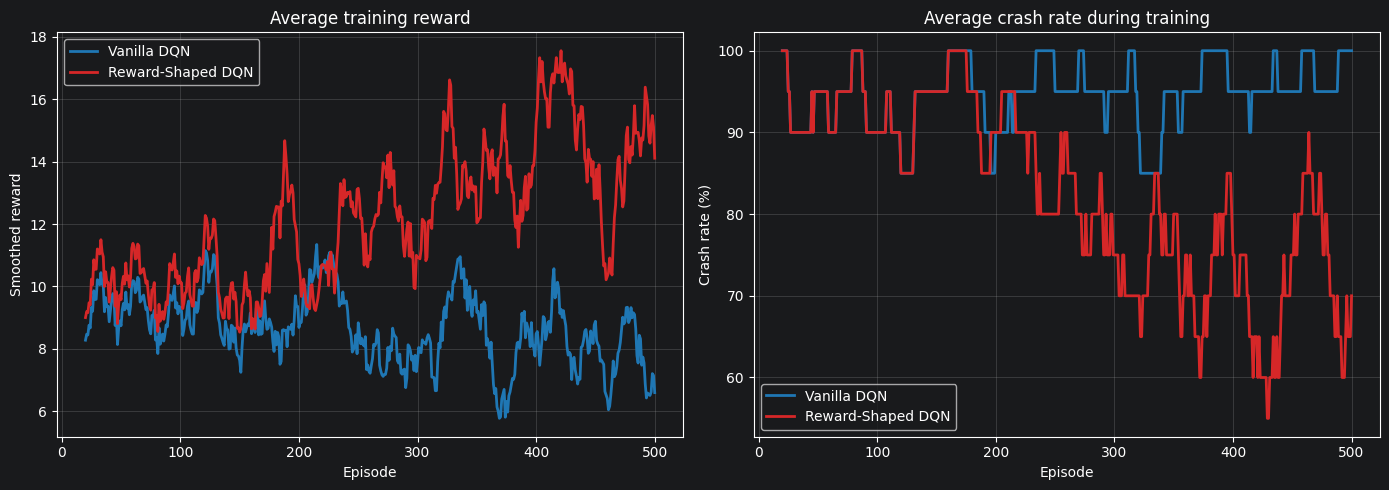

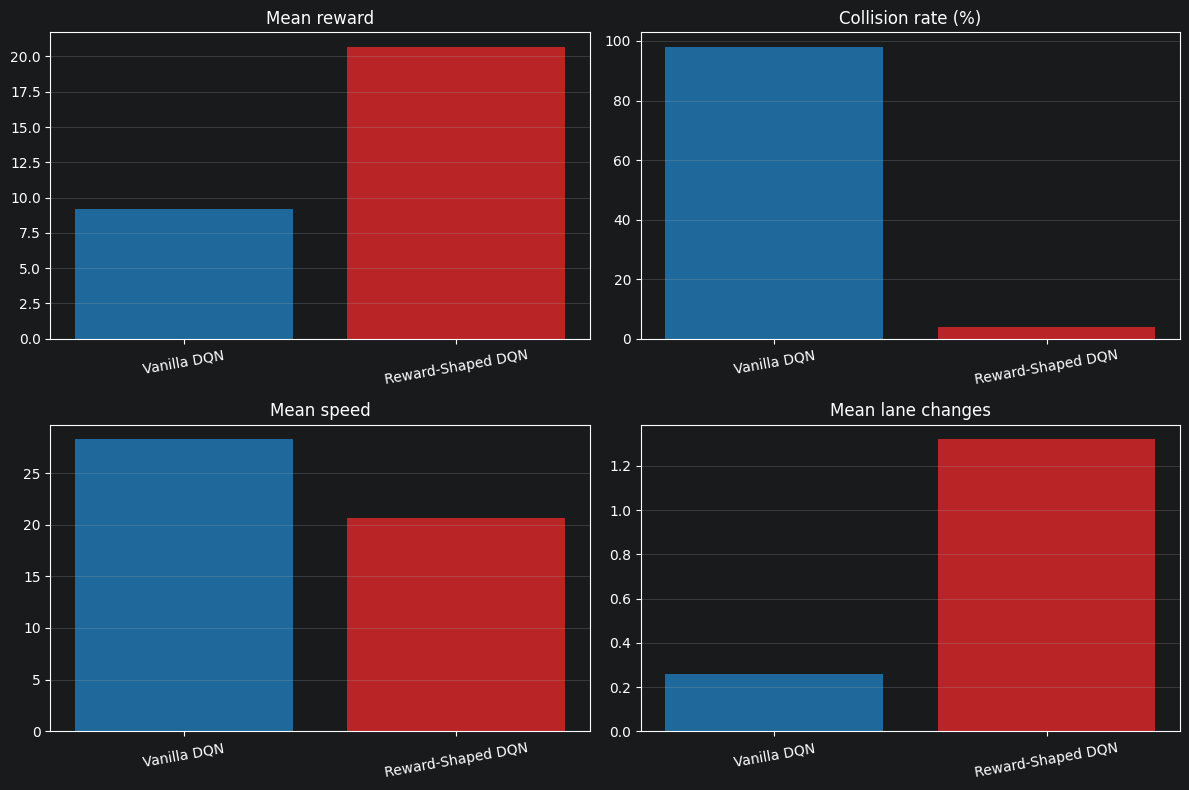

'results\\reward_shaping_extension\\summary_comparison.png'

In [5]:
plot_training_comparison(study, output_dir=OUTPUT_DIR)
plot_summary_comparison(study, output_dir=OUTPUT_DIR)


## Extension-specific failure analysis

using the reward-shaped checkpoint we save/output our failure plot.



 FAILURE ANALYSIS REPORT
  Crashes  : 12 / 200  (6.0%)
  Successes: 188 / 200  (94.0%)

  Crash timing: mean=13.9 steps, min=5, max=25
  Crashes within first 10 steps: 5 (42%)

  Last action before crash:
    SLOWER          6  (50%)
    LANE_RIGHT      4  (33%)
    LANE_LEFT       1  (8%)
    IDLE            1  (8%)
    FASTER          0  (0%)

  Mean reward — crashes  : 11.03
  Mean reward — successes: 24.99
  Reward gap: 13.96 (how much surviving is worth)

-----------------------------------------------------------------
 INTERPRETATION
-----------------------------------------------------------------

  Most common crash action: SLOWER (50% of crashes)

  42% of crashes occur in ≤10 steps.
  → Some failures may be caused by unavoidable spawn configurations,
    not poor policy. This is a known limitation of the environment.

Saved → results\reward_shaping_extension\reward_shaped_failure_analysis\failure_analysis.png


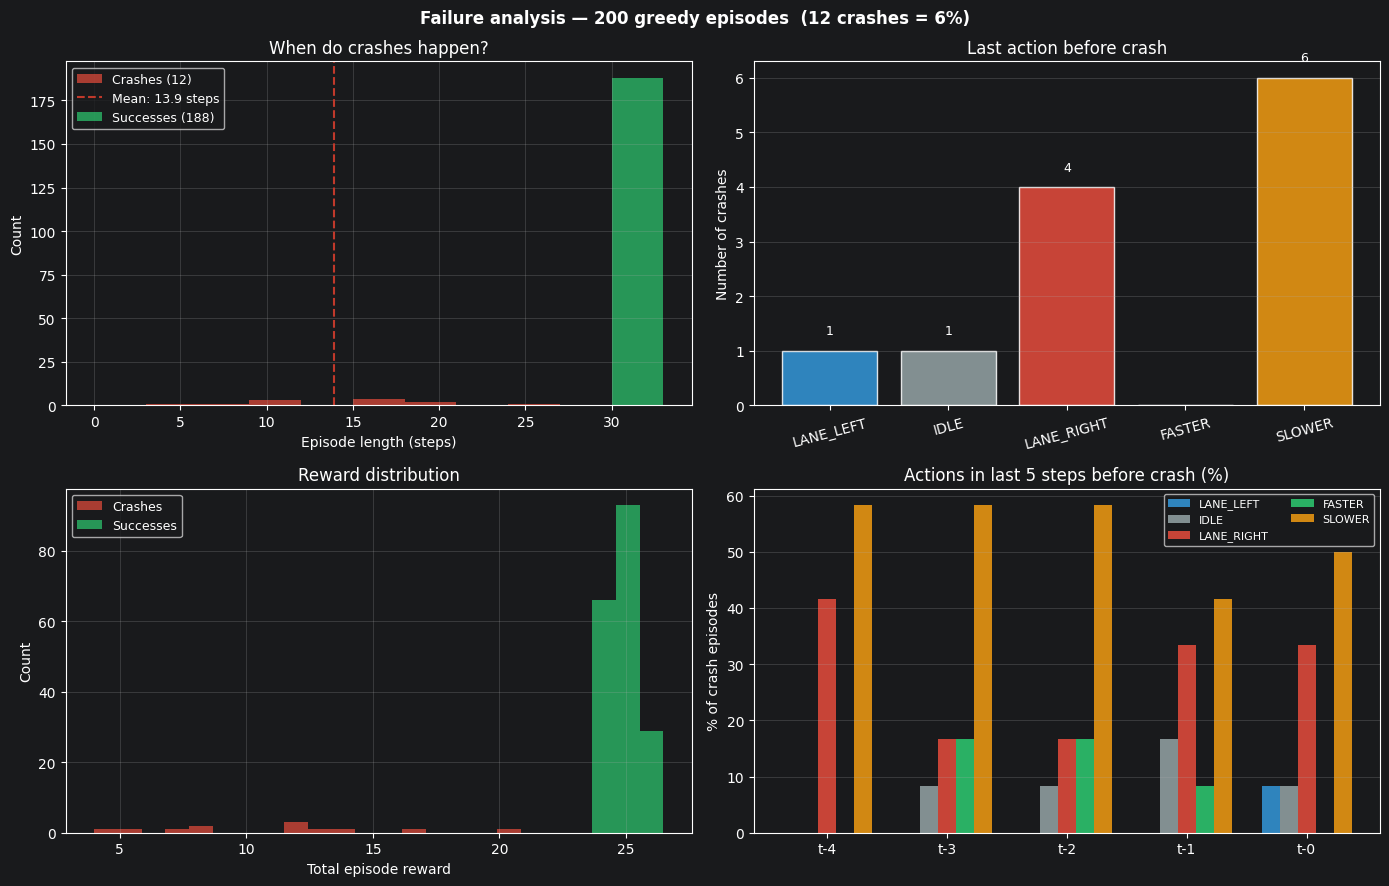

{'variant': 'reward_shaped',
 'seed': 0,
 'checkpoint': 'checkpoints\\reward_shaping_extension\\reward_shaped_seed0_best.pt',
 'save_dir': 'results\\reward_shaping_extension\\reward_shaped_failure_analysis',
 'plot_path': 'results\\reward_shaping_extension\\reward_shaped_failure_analysis\\failure_analysis.png',
 'n_failures': 12,
 'n_successes': 188}

In [6]:
failure_result = run_failure_analysis(
    variant='reward_shaped',
    seed=0,
    n_episodes=200,
    checkpoint_dir=CHECKPOINT_DIR,
    output_dir=OUTPUT_DIR,
)

failure_result


## Extension-specific rollout video

we record a greedy rollout video using the reward-shaped checkpoint and save it to the output directory.

In [7]:
video_result = record_variant_video(
    variant='reward_shaped',
    seed=0,
    n_episodes=3,
    checkpoint_dir=CHECKPOINT_DIR,
    output_dir=OUTPUT_DIR,
)

video_result


C:\Users\ziadn\IdeaProjects\rl-highway-project-grp15\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at C:\Users\ziadn\IdeaProjects\rl-highway-project-grp15\results\reward_shaping_extension\video\reward_shaped folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


{'variant': 'reward_shaped',
 'seed': 0,
 'checkpoint': 'checkpoints\\reward_shaping_extension\\reward_shaped_seed0_best.pt',
 'video_dir': 'results\\reward_shaping_extension\\video\\reward_shaped',
 'mean_reward': 25.114876441896573,
 'rewards': [25.584677419354843, 24.31338289743934, 25.446569008895537]}

In [8]:
# study = load_study(OUTPUT_DIR)
# print_study_summary(study)
# summary_rows(study)
